# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Pranavi B
**Course:** MSCS 634 – Your Course Title
**Lab Assignment:** Lab 3 – Clustering Analysis Using K-Means and K-Medoids Algorithms

This notebook applies two partition-based clustering algorithms, **K-Means** and **K-Medoids**, to the **Wine dataset** from scikit-learn. Both models are evaluated with the **Silhouette Score** (cluster quality without labels) and the **Adjusted Rand Index** (agreement with the true wine classes), and the results are compared visually and numerically.

## Step 1: Load and Prepare the Dataset

### 1.1 Import libraries and load the data

The Wine dataset contains chemical analysis results for 178 wines grown in the same region of Italy by three different cultivators (classes `class_0`, `class_1`, `class_2`). Each wine is described by 13 continuous features.

In [1]:
# Core libraries for data handling
import numpy as np
import pandas as pd

# Dataset loader from scikit-learn
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()

X = wine.data      # feature matrix (178 x 13)
y = wine.target    # true class labels (used only for evaluation, never for training)

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Number of Samples:", X.shape[0])

Dataset Shape: (178, 13)
Number of Features: 13
Number of Samples: 178


In [2]:
# List the 13 chemical features in the dataset
print("Feature Names:")
for feature in wine.feature_names:
    print(feature)

Feature Names:
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


### 1.2 Basic data exploration

The feature matrix is converted to a pandas DataFrame so it can be inspected more easily.

In [3]:
# Put the features into a DataFrame for easier exploration
wine_df = pd.DataFrame(X, columns=wine.feature_names)

print("First 10 Rows:")
display(wine_df.head(10))

# Data types and non-null counts for every column
print("\nDataset Information:")
wine_df.info()

First 10 Rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64

In [4]:
# Summary statistics for each feature (mean, std, min, max, quartiles)
print("Summary Statistics:")
display(wine_df.describe().T.round(2))

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


The summary statistics show that the features are on very different scales. For example, `proline` ranges from roughly 278 to 1680, while `hue` ranges from about 0.48 to 1.71 and `nonflavanoid_phenols` stays below 1. Because both K-Means and K-Medoids rely on Euclidean distance, features with large numeric ranges would dominate the distance calculation if the data were left unscaled. This is the reason standardization is applied in Step 1.4.

In [5]:
# Count how many wines belong to each class
print("Class Distribution:")
class_distribution = pd.Series(y).value_counts().sort_index()
print(class_distribution)

# Map the numeric labels to their class names
print("\nClass Names:")
for i, name in enumerate(wine.target_names):
    print(i, "=", name)

Class Distribution:
0    59
1    71
2    48
Name: count, dtype: int64

Class Names:
0 = class_0
1 = class_1
2 = class_2


The classes are moderately imbalanced (59 / 71 / 48) but no class is very small, so no resampling is needed. Since the dataset has three known classes, **k = 3** is the natural choice for both clustering algorithms.

### 1.3 Data cleaning: missing values, duplicates, and outliers

Before clustering, the data is checked for three common quality issues.

In [6]:
# 1) Missing values: count nulls in every column
missing_values = wine_df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print("\nTotal missing values:", missing_values.sum())

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Total missing values: 0


In [7]:
# 2) Duplicate rows: identical wines would be double-counted by the clustering algorithms
duplicate_count = wine_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# 3) Outliers: flag any value more than 3 standard deviations from its feature mean
z_scores = np.abs((wine_df - wine_df.mean()) / wine_df.std(ddof=0))
outlier_mask = z_scores > 3

print("Outlier values (|z| > 3) per feature:")
print(outlier_mask.sum()[outlier_mask.sum() > 0])
print("\nTotal outlier values:", outlier_mask.values.sum())
print("Rows containing at least one outlier:", outlier_mask.any(axis=1).sum())

Outlier values (|z| > 3) per feature:
malic_acid           1
ash                  3
alcalinity_of_ash    1
magnesium            2
flavanoids           1
proanthocyanins      1
color_intensity      1
hue                  1
dtype: int64

Total outlier values: 11
Rows containing at least one outlier: 10


**Cleaning decisions:**

- **Missing values:** None were found in any of the 13 features, so no imputation or row removal was required.
- **Duplicates:** No duplicate rows exist, so every observation is kept.
- **Outliers:** 11 individual values (in 10 of the 178 rows) lie more than 3 standard deviations from their feature mean, most often in `ash` and `magnesium`. These rows were **kept**. The values are plausible chemical measurements rather than recording errors, and removing 10 rows (about 6% of the data) would shrink an already small dataset and change the class balance. Keeping them is also useful for this lab, because sensitivity to outliers is one of the main differences between K-Means and K-Medoids.

### 1.4 Standardize the features (z-score normalization)

`StandardScaler` transforms each feature to have a mean of 0 and a standard deviation of 1, using z = (x − mean) / std. After scaling, every feature contributes equally to the distance calculations used by both clustering algorithms.

In [9]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on the features and transform them to z-scores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized Dataset Shape:", X_scaled.shape)
print("\nFirst 5 Standardized Rows:")
print(X_scaled[:5].round(3))

Standardized Dataset Shape: (178, 13)

First 5 Standardized Rows:
[[ 1.519 -0.562  0.232 -1.17   1.914  0.809  1.035 -0.66   1.225  0.252
   0.362  1.848  1.013]
 [ 0.246 -0.499 -0.828 -2.491  0.018  0.569  0.734 -0.821 -0.545 -0.293
   0.406  1.113  0.965]
 [ 0.197  0.021  1.109 -0.269  0.088  0.809  1.216 -0.498  2.136  0.269
   0.318  0.789  1.395]
 [ 1.692 -0.347  0.488 -0.809  0.931  2.491  1.467 -0.982  1.032  1.186
  -0.428  1.184  2.335]
 [ 0.296  0.228  1.84   0.452  1.282  0.809  0.663  0.227  0.401 -0.319
   0.362  0.45  -0.038]]


In [10]:
# Verify the scaling: every feature should now have mean ~0 and std = 1
print("Means after standardization:")
print(np.mean(X_scaled, axis=0).round(6))

print("\nStandard deviations after standardization:")
print(np.std(X_scaled, axis=0))

Means after standardization:
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Standard deviations after standardization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The means are effectively zero (any remaining digits are floating-point rounding) and every standard deviation is 1, confirming the data is properly standardized. `X_scaled` is used for both clustering models so the comparison is fair.

## Step 2: Implement K-Means Clustering

K-Means assigns each observation to the nearest of *k* cluster centers and then moves each center to the **mean** of its assigned points, repeating until the assignments stop changing. The algorithm minimizes the within-cluster sum of squared distances (inertia).

**Parameter choices:**

| Parameter | Value | Reason |
|---|---|---|
| `n_clusters` | 3 | The Wine dataset has three true classes. |
| `n_init` | 10 | K-Means can converge to a poor local minimum depending on the starting centers. Running it 10 times with different initializations and keeping the lowest-inertia result makes the solution more reliable. |
| `random_state` | 42 | Fixes the random initialization so the results are reproducible. |
| `init` | `k-means++` (default) | Spreads the initial centers apart, which usually speeds up convergence and improves the final result. |

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Create the K-Means model with the parameters described above
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the model on the standardized data
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 13)","[[-0

In [12]:
# Cluster label assigned to each wine
kmeans_labels = kmeans.labels_

print("K-Means Cluster Labels:")
print(kmeans_labels)

# Number of wines in each cluster
print("\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Cluster sizes:
0    65
1    51
2    62
Name: count, dtype: int64


In [13]:
# Coordinates of the three centroids in the 13-dimensional standardized space
print("K-Means Cluster Centers:")
print(kmeans.cluster_centers_.round(3))

K-Means Cluster Centers:
[[-0.926 -0.394 -0.495  0.171 -0.492 -0.076  0.021 -0.034  0.058 -0.902
   0.462  0.271 -0.754]
 [ 0.165  0.872  0.187  0.524 -0.075 -0.979 -1.215  0.726 -0.78   0.942
  -1.165 -1.292 -0.407]
 [ 0.835 -0.304  0.365 -0.61   0.578  0.885  0.978 -0.562  0.58   0.171
   0.474  0.779  1.125]]


### 2.1 Evaluate K-Means

- **Silhouette Score** ranges from −1 to 1. It compares how close each point is to its own cluster versus the nearest other cluster. Higher values mean tighter, better-separated clusters. It does not use the true labels.
- **Adjusted Rand Index (ARI)** measures agreement between the cluster assignments and the true class labels, corrected for chance. A value of 1 means perfect agreement and 0 means no better than random.

In [14]:
# Silhouette Score: cluster cohesion vs. separation (no true labels needed)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

# ARI: agreement between the clusters and the true wine classes
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-MEANS RESULTS")
print("-------------------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Adjusted Rand Index (ARI):", round(kmeans_ari, 4))

K-MEANS RESULTS
-------------------------
Number of Clusters: 3
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975


In [15]:
# Cross-tabulate true classes against K-Means clusters to see where errors occur
print("True class (rows) vs. K-Means cluster (columns):")
display(pd.crosstab(
    pd.Series(wine.target_names[y], name="True class"),
    pd.Series(kmeans_labels, name="K-Means cluster")
))

True class (rows) vs. K-Means cluster (columns):


K-Means cluster,0,1,2
True class,,,
class_0,0,0,59
class_1,65,3,3
class_2,0,48,0


K-Means achieves an ARI of about **0.90**, meaning its clusters closely match the three wine classes. The cross-tabulation shows that all of `class_0` and `class_2` fall into their own clusters, and only 6 of the 71 `class_1` wines are placed in the wrong cluster. The Silhouette Score of about **0.28** is moderate, which indicates the clusters overlap somewhat in the full 13-dimensional space even though they align well with the true classes.

## Step 3: Implement K-Medoids Clustering

K-Medoids works like K-Means, but each cluster center must be an **actual observation** from the dataset (a *medoid*) rather than a calculated mean. The algorithm picks the medoids that minimize the total distance between each point and its cluster's medoid. Because a single extreme value cannot pull a medoid away from the data the way it can shift a mean, K-Medoids is generally more robust to outliers.

K-Medoids is not part of core scikit-learn, so the `KMedoids` class from the **scikit-learn-extra** package is used (`pip install scikit-learn-extra`).

**Parameter choices:**

| Parameter | Value | Reason |
|---|---|---|
| `n_clusters` | 3 | Matches the three true classes and the K-Means model, so the comparison is fair. |
| `metric` | `euclidean` | The same distance measure K-Means uses. Keeping it identical means any difference in results comes from the algorithm itself, not the distance definition. |
| `random_state` | 42 | Same seed as K-Means, for reproducibility. |
| `method` | `alternate` (default) | Alternates between assigning points to the nearest medoid and updating each medoid, similar to K-Means. It is fast on a dataset of this size. |
| `init` | `heuristic` (default) | Chooses the starting medoids as the points with the smallest total distance to all others. |

In [16]:
from sklearn_extra.cluster import KMedoids

# Create the K-Medoids model with the parameters described above
kmedoids = KMedoids(
    n_clusters=3,
    random_state=42,
    metric="euclidean"
)

# Train the model on the same standardized data used for K-Means
kmedoids.fit(X_scaled)

,n_clusters,3
,random_state,42
,metric,'euclidean'
,method,'alternate'
,init,'heuristic'
,max_iter,300
Name,Type,Value
cluster_centers_,"ndarray[float64](3, 13)","[[ 0.49, 1.41, 0.41,...,-1.13,-1.49, 0.01], [-0.93,-0.54,-0.9 ,..., 0.19, 0.79,-0.75], [ 0.59,-0.47, 0.16,..., 0.36, 1.21, 0.55]]"
inertia_,float64,501
labels_,"ndarray[int64](178,)","[2,2,2,...,0,0,0]"
medoid_indices_,"ndarray[int64](3,)","[174,106, 35]"


In [17]:
# Cluster label assigned to each wine
kmedoids_labels = kmedoids.labels_

print("K-Medoids Cluster Labels:")
print(kmedoids_labels)

# Number of wines in each cluster
print("\nCluster sizes:")
print(pd.Series(kmedoids_labels).value_counts().sort_index())

K-Medoids Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 2 1 1 1 2 1 2 1 2
 2 1 1 1 1 2 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 2 0 1 2 1 1 1 1 1 1 1 1 1 1 2 2
 1 1 1 1 1 1 1 1 1 2 2 0 1 2 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Cluster sizes:
0    51
1    54
2    73
Name: count, dtype: int64


In [18]:
# The medoids are real wines; these are their row indices in the dataset
print("K-Medoids Medoid Indices:")
print(kmedoids.medoid_indices_)

# Their standardized feature values
print("\nK-Medoids Medoids:")
print(kmedoids.cluster_centers_.round(3))

K-Medoids Medoid Indices:
[174 106  35]

K-Medoids Medoids:
[[ 4.930e-01  1.413e+00  4.150e-01  1.053e+00  1.590e-01 -7.930e-01
  -1.284e+00  5.490e-01 -3.170e-01  9.700e-01 -1.130e+00 -1.485e+00
   1.000e-02]
 [-9.270e-01 -5.440e-01 -9.010e-01 -1.490e-01 -1.386e+00 -1.034e+00
   1.000e-03  6.600e-02  6.900e-02 -7.170e-01  1.870e-01  7.890e-01
  -7.540e-01]
 [ 5.920e-01 -4.720e-01  1.590e-01  3.020e-01  1.800e-02  6.490e-01
   9.550e-01 -8.210e-01  4.710e-01  1.800e-02  3.620e-01  1.212e+00
   5.510e-01]]


### 3.1 Evaluate K-Medoids

The same two metrics are calculated so the results can be compared directly with K-Means.

In [19]:
# Silhouette Score and ARI for K-Medoids
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-MEDOIDS RESULTS")
print("-------------------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", round(kmedoids_silhouette, 4))
print("Adjusted Rand Index (ARI):", round(kmedoids_ari, 4))

K-MEDOIDS RESULTS
-------------------------
Number of Clusters: 3
Silhouette Score: 0.266
Adjusted Rand Index (ARI): 0.7263


In [20]:
# Cross-tabulate true classes against K-Medoids clusters
print("True class (rows) vs. K-Medoids cluster (columns):")
display(pd.crosstab(
    pd.Series(wine.target_names[y], name="True class"),
    pd.Series(kmedoids_labels, name="K-Medoids cluster")
))

True class (rows) vs. K-Medoids cluster (columns):


K-Medoids cluster,0,1,2
True class,,,
class_0,0,0,59
class_1,3,54,14
class_2,48,0,0


K-Medoids reaches an ARI of about **0.73** and a Silhouette Score of about **0.27**, both lower than K-Means. The cross-tabulation shows where the difference comes from: `class_0` and `class_2` are still clustered perfectly, but 17 of the 71 `class_1` wines are misplaced, 14 of them into the cluster that contains `class_0`.

## Step 4: Visualize and Compare Results

### 4.1 Side-by-side cluster plots

The data has 13 dimensions, so **Principal Component Analysis (PCA)** is used to project it onto two dimensions for plotting. PCA is used only for visualization; both models were trained on the full 13-feature data. The centroids and medoids are projected with the same PCA transformation so they appear in the correct positions. A third panel shows the true wine classes as a reference.

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce the standardized data to 2 principal components for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much of the original variance the 2-D view keeps
var1, var2 = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {var1:.1f}% of the variance")
print(f"PC2 explains {var2:.1f}% of the variance")
print(f"Total variance shown in the plots: {var1 + var2:.1f}%")

# Project the cluster centers into the same 2-D space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_centers_pca = pca.transform(kmedoids.cluster_centers_)

PC1 explains 36.2% of the variance
PC2 explains 19.2% of the variance
Total variance shown in the plots: 55.4%


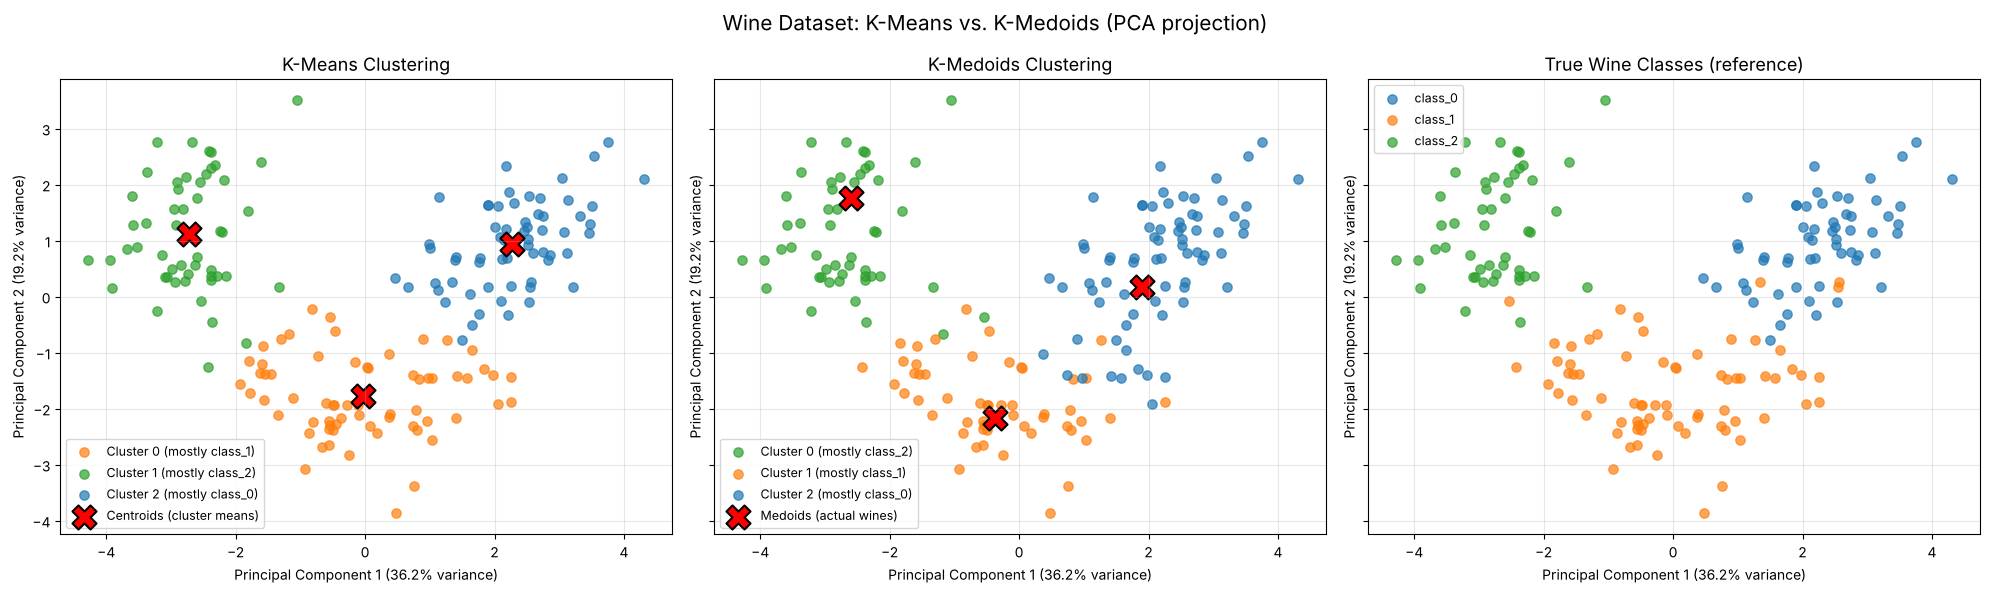

In [22]:
# Axis labels include the variance explained by each component
x_label = f"Principal Component 1 ({var1:.1f}% variance)"
y_label = f"Principal Component 2 ({var2:.1f}% variance)"

# Cluster numbers are arbitrary, so each cluster is matched to the true class
# that most of its members belong to. That class's color is then used in every
# panel, which makes the three plots directly comparable.
class_colors = ["tab:blue", "tab:orange", "tab:green"]

def majority_class(labels):
    # Returns {cluster number: most common true class in that cluster}
    return {c: np.bincount(y[labels == c]).argmax() for c in np.unique(labels)}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

panels = [
    ("K-Means Clustering", kmeans_labels, kmeans_centers_pca, "Centroids (cluster means)"),
    ("K-Medoids Clustering", kmedoids_labels, kmedoids_centers_pca, "Medoids (actual wines)"),
    ("True Wine Classes (reference)", y, None, None),
]

for ax, (title, labels, centers, center_label) in zip(axes, panels):
    mapping = majority_class(labels) if centers is not None else {c: c for c in range(3)}

    # Plot each group separately so it gets its own legend entry
    for group in np.unique(labels):
        mask = labels == group
        matched = mapping[group]
        if centers is None:
            name = wine.target_names[group]
        else:
            name = f"Cluster {group} (mostly {wine.target_names[matched]})"
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=45, alpha=0.7,
                   color=class_colors[matched], label=name)

    # Mark the centroids / medoids with a large X
    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=300,
                   edgecolor="black", linewidth=1.5, label=center_label)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)

plt.suptitle("Wine Dataset: K-Means vs. K-Medoids (PCA projection)", fontsize=15)
plt.tight_layout()
plt.show()

**What the plots show:**

Each cluster is colored by the true class most of its members belong to, so matching colors across the three panels mean the same group of wines.

- **Overall structure:** The data forms a U shape. `class_2` sits in the upper left, `class_0` in the upper right, and `class_1` along the bottom, connecting the two. The two upper groups are clearly separated from each other, but `class_1` touches both of them.
- **K-Means:** The clusters closely match the true-class panel. Only a few borderline points differ. Each red centroid sits near the visual center of its group, because a centroid is the average of its points.
- **K-Medoids:** The upper-left cluster matches K-Means and the true classes. The difference is on the right side: the medoid of the `class_0` cluster sits lower than the K-Means centroid, closer to `class_1`. As a result, a group of `class_1` wines in the lower right (roughly PC1 between 0.5 and 2) is pulled into the green `class_0` cluster. This matches the 14 misplaced wines in the cross-tabulation. The medoids are real wines, so they sit on actual data points and are noticeably off-center compared with the centroids.
- **Limitation of the view:** The two components keep only about 55% of the total variance, so some points that look close in 2-D are farther apart in the full 13-dimensional space. This also explains why the Silhouette Scores are moderate even though the groups look fairly distinct in the plots.

### 4.2 Metric comparison

In [23]:
# Collect both models' results in one table
results = pd.DataFrame({
    "K-Means": [3, kmeans_silhouette, kmeans_ari],
    "K-Medoids": [3, kmedoids_silhouette, kmedoids_ari],
}, index=["Number of Clusters", "Silhouette Score", "Adjusted Rand Index (ARI)"])

display(results.round(4))

,K-Means,K-Medoids
Number of Clusters,3.0000,3.0000
Silhouette Score,0.2849,0.2660
Adjusted Rand Index (ARI),0.8975,0.7263


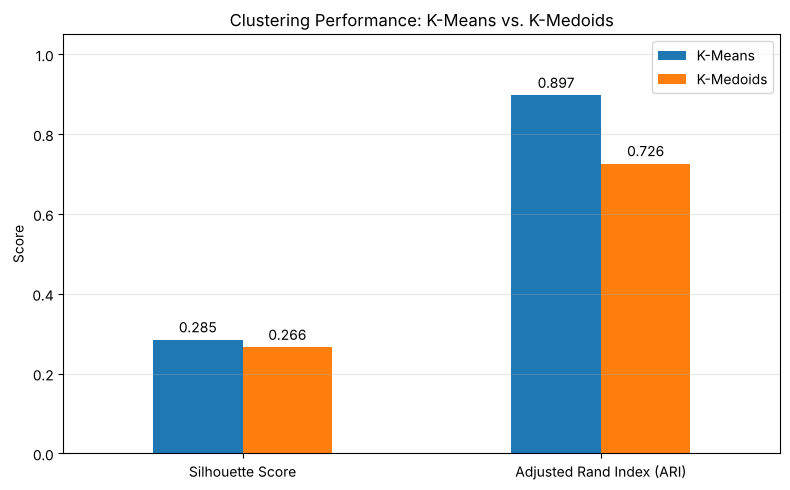

In [24]:
# Bar chart comparing the two evaluation metrics
fig, ax = plt.subplots(figsize=(8, 5))
results.loc[["Silhouette Score", "Adjusted Rand Index (ARI)"]].plot(kind="bar", ax=ax, rot=0)

# Print the value on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.set_title("Clustering Performance: K-Means vs. K-Medoids")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Analysis

**Which algorithm produced better-defined clusters?**

K-Means performed better on both metrics. Its Silhouette Score (0.2849 vs. 0.2660) shows slightly tighter and better-separated clusters, and its ARI (0.8975 vs. 0.7263) shows much stronger agreement with the true wine classes. The silhouette gap is small, but the ARI gap is large: K-Means misplaced 6 of 178 wines, while K-Medoids misplaced 17.

**What differences appear in cluster shapes or positioning?**

- The two outer clusters (`class_0` and `class_2`) are essentially the same for both algorithms. All of the disagreement is in the middle `class_1` group, which overlaps with its neighbors.
- K-Means centroids sit at the geometric center of each group. The K-Medoids medoids must be real wines (rows 174, 106 and 35), so they are positioned on actual data points and sit slightly off-center.
- Because each K-Medoids cluster is anchored to a single real wine, the medoid of the `class_0` cluster sits closer to the `class_1` group than the K-Means centroid does. As a result, the `class_1` wines lying between the two groups are assigned to the `class_0` cluster, which is why K-Medoids' ARI drops.
- Both Silhouette Scores are only around 0.27–0.28. This means the clusters overlap considerably in 13 dimensions, so small shifts in where a center sits can move many borderline wines from one cluster to another.

**Why did K-Means do better here?**

After standardization, the Wine data forms fairly compact, roughly round groups, which is the shape K-Means assumes. The dataset has only 10 rows with mild outliers, so K-Medoids' main advantage, robustness to extreme values, has little to work with. Meanwhile, K-Means' ability to place a center anywhere (not only on a data point) lets it find a better boundary through the overlapping middle class.

**When is each algorithm preferable?**

- **K-Means** is preferable when the features are numeric and scaled, the clusters are compact and roughly spherical, outliers are few, and the dataset is large. It is fast (roughly linear in the number of points) and works well when a mean is a meaningful summary of a group.
- **K-Medoids** is preferable when the data contains significant outliers or noise, when a distance other than Euclidean is needed (for example Manhattan, or a custom dissimilarity for categorical data), or when each cluster must be represented by a real example, such as choosing a representative customer, product, or document. Its drawback is a higher computational cost, since it works with pairwise distances, which makes it slower on large datasets.

**Conclusion:** For the standardized Wine dataset, K-Means is the better choice. It recovers the three cultivars with about 90% chance-adjusted agreement, while K-Medoids, though still reasonable, struggles with the overlapping middle class.